# Демонстрация — классификация постеров по жанрам

Локальный запуск без PyTorch. Нужен файл `model.onnx` (обученный в Google Colab) рядом с этим ноутбуком.

## Установка зависимостей (один раз)

In [1]:
import sys, subprocess, importlib

for mod, pkg in [("onnxruntime", "onnxruntime"), ("PIL", "Pillow"),
                 ("numpy", "numpy"), ("matplotlib", "matplotlib")]:
    if importlib.util.find_spec(mod) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("Зависимости готовы.")

Зависимости готовы.


## Загрузка модели

In [2]:
import json, os
import numpy as np
import onnxruntime as ort

ONNX_PATH       = "model.onnx"
THRESHOLDS_PATH = "thresholds.json"
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

sess = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])

# Размер входа берём из самой ONNX-модели — работает и для 224, и для 384.
in_shape = sess.get_inputs()[0].shape  # [batch, 3, H, W]
IMG_SIZE = in_shape[2] if isinstance(in_shape[2], int) else 224

if os.path.exists(THRESHOLDS_PATH):
    with open(THRESHOLDS_PATH) as f:
        thr_map = json.load(f)
    GENRE_COLS = list(thr_map.keys())
    THRESHOLDS = np.array(list(thr_map.values()), dtype=np.float32)
    print(f"IMG_SIZE={IMG_SIZE}; жанров: {len(GENRE_COLS)}; пороги из {THRESHOLDS_PATH}.")
else:
    GENRE_COLS = ['Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror',
                  'Music', 'Musical', 'Mystery', 'N/A', 'News', 'Reality-TV',
                  'Romance', 'Sci-Fi', 'Short', 'Sport', 'Thriller', 'War', 'Western']
    THRESHOLDS = np.full(len(GENRE_COLS), 0.5, dtype=np.float32)
    print(f"IMG_SIZE={IMG_SIZE}; жанров: {len(GENRE_COLS)}; thresholds.json не найден, порог 0.5.")


IMG_SIZE=384; жанров: 25; thresholds.json не найден, порог 0.5.


## Предсказание

Запусти ячейку — откроется диалог выбора файла.

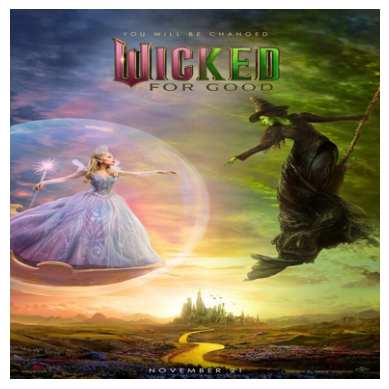

Предсказанные жанры:
  Adventure          98.31%  (порог 0.50)
  Family             62.95%  (порог 0.50)
  Action             59.03%  (порог 0.50)

Топ-5 по вероятности:
  Adventure          98.31%
  Family             62.95%
  Action             59.03%
  Animation          37.90%
  Comedy             21.91%


In [53]:
import tkinter as tk
from tkinter import filedialog
from PIL import Image
import matplotlib.pyplot as plt

root = tk.Tk(); root.withdraw(); root.attributes("-topmost", True)
path = filedialog.askopenfilename(
    title="Выберите постер",
    filetypes=[("Изображения", "*.jpg *.jpeg *.png *.webp *.bmp"), ("Все файлы", "*.*")],
)
root.destroy()
if not path:
    raise RuntimeError("Файл не выбран.")

img = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
arr = (np.asarray(img, dtype=np.float32) / 255.0 - MEAN) / STD
arr = arr.transpose(2, 0, 1)[None]

logits = sess.run(None, {"input": arr})[0][0]
probs = 1.0 / (1.0 + np.exp(-logits))

plt.imshow(img); plt.axis("off"); plt.show()

# Жанры, прошедшие свой персональный порог.
predicted = [(g, p, t) for g, p, t in zip(GENRE_COLS, probs, THRESHOLDS) if p > t]
predicted.sort(key=lambda x: -x[1])
print("Предсказанные жанры:" if predicted else "Уверенных жанров не найдено.")
for g, p, t in predicted:
    print(f"  {g:18s} {p:.2%}  (порог {t:.2f})")

print("\nТоп-5 по вероятности:")
for g, p in sorted(zip(GENRE_COLS, probs), key=lambda x: -x[1])[:5]:
    print(f"  {g:18s} {p:.2%}")
